In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [2]:
date = {
    "Alina": [60, 165, True],
    "Bogdan": [72, 183, False],
    "Ciprian": [69, 178, False],
    "Diana": [55, 152, True],
    "Elena": [58, 168, True],
    "Andrei": [80, 185, False],
    "Mihai": [75, 177, False],
    "Irina": [62, 170, True],
    "Florin": [90, 190, False],
    "Maria": [53, 160, True],
    "Vlad": [70, 175, False],
    "Ioana": [50, 155, True],
    "Radu": [68, 172, False],
    "Ana": [59, 162, True],
    "George": [85, 182, False],
    "Larisa": [61, 167, True],
    "Stefan": [78, 180, False],
    "Bianca": [56, 158, True],
    "Paul": [74, 176, False],
    "Oana": [54, 163, True],
    "Cosmin": [82, 188, False],
    "Teodora": [57, 159, True],
    "Ionut": [76, 181, False],
    "Gabriela": [60, 164, True]
}

In [4]:
df = pd.DataFrame(date)
df

,Alina,Bogdan,Ciprian,Diana,Elena,Andrei,Mihai,Irina,Florin,Maria,...,George,Larisa,Stefan,Bianca,Paul,Oana,Cosmin,Teodora,Ionut,Gabriela
0,60,72,69,55,58,80,75,62,90,53,...,85,61,78,56,74,54,82,57,76,60
1,165,183,178,152,168,185,177,170,190,160,...,182,167,180,158,176,163,188,159,181,164
2,True,False,False,True,True,False,False,True,False,True,...,False,True,False,True,False,True,False,True,False,True


In [8]:
df = pd.DataFrame(date.values(), columns=["Kg", "Cm", "Voce_subtire"])
df.head()

,Kg,Cm,Voce_subtire
0,60,165,True
1,72,183,False
2,69,178,False
3,55,152,True
4,58,168,True


In [9]:
df["Voce_subtire"] = df["Voce_subtire"].astype(int)
df.head()

,Kg,Cm,Voce_subtire
0,60,165,1
1,72,183,0
2,69,178,0
3,55,152,1
4,58,168,1


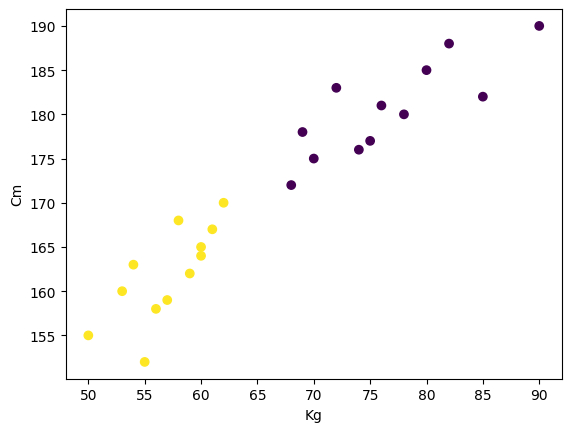

In [11]:
plt.scatter(df["Kg"], df["Cm"], c=df["Voce_subtire"])
plt.xlabel("Kg")
plt.ylabel("Cm")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
y = df["Voce_subtire"]
x = df
x.shape

(24, 3)

In [15]:
standard_scaler = StandardScaler()
standard_scaler


StandardScaler()

In [16]:
standard_scaler.fit(x)
x_scaled = standard_scaler.transform(x)
x_scaled

array([[-0.61915453, -0.58660023,  1.        ],
       [ 0.46814123,  1.10280844, -1.        ],
       [ 0.19631729,  0.63352825, -1.        ],
       [-1.07219444, -1.80672872,  1.        ],
       [-0.8003705 , -0.30503212,  1.        ],
       [ 1.19300508,  1.29052052, -1.        ],
       [ 0.73996518,  0.53967222, -1.        ],
       [-0.43793857, -0.11732005,  1.        ],
       [ 2.09908489,  1.7598007 , -1.        ],
       [-1.2534104 , -1.05588042,  1.        ],
       [ 0.28692527,  0.35196014, -1.        ],
       [-1.52523434, -1.52516061,  1.        ],
       [ 0.10570931,  0.07039203, -1.        ],
       [-0.70976252, -0.86816835,  1.        ],
       [ 1.64604498,  1.0089524 , -1.        ],
       [-0.52854655, -0.39888816,  1.        ],
       [ 1.01178912,  0.82124033, -1.        ],
       [-0.98158646, -1.2435925 ,  1.        ],
       [ 0.64935719,  0.44581618, -1.        ],
       [-1.16280242, -0.77431231,  1.        ],
       [ 1.37422104,  1.57208863, -1.   

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((19, 3), (5, 3), (19,), (5,))

In [22]:
model = tf.keras.Sequential(
    [
      ## Input
      tf.keras.Input(shape=(3,)),

      tf.keras.layers.Dense(16, activation="relu"),
      tf.keras.layers.Dense(16, activation="relu"),

      #Ouput layer
      tf.keras.layers.Dense(1, activation="sigmoid"),

    ]
)
model.summary()
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]);

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_history = model.fit(x_train, y_train, epochs=100, validation_split=0.2)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6667 - loss: 0.6416 - val_accuracy: 1.0000 - val_loss: 0.5377
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7333 - loss: 0.6343 - val_accuracy: 1.0000 - val_loss: 0.5358
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7333 - loss: 0.6271 - val_accuracy: 1.0000 - val_loss: 0.5339
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7333 - loss: 0.6200 - val_accuracy: 1.0000 - val_loss: 0.5319
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8667 - loss: 0.6129 - val_accuracy: 1.0000 - val_loss: 0.5301
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8667 - loss: 0.6060 - val_accuracy: 1.0000 - val_loss: 0.5281
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8667 - loss: 0.5993 - val_accuracy: 1.0000 - val_loss: 0.5262
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9333 - loss: 0.5927 - val_accuracy: 1.0000 - val_loss: 0

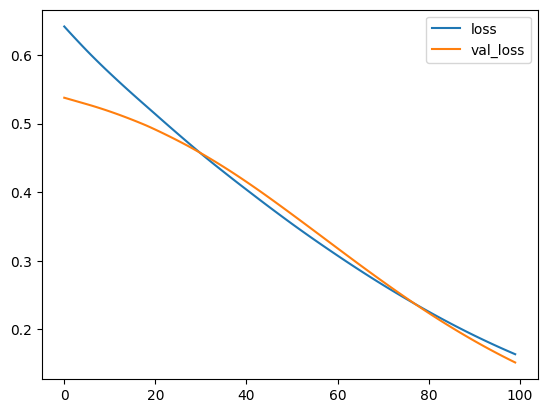

In [24]:
plt.plot(model_history.history["loss"], label="loss")
plt.plot(model_history.history["val_loss"], label="val_loss")
plt.legend()

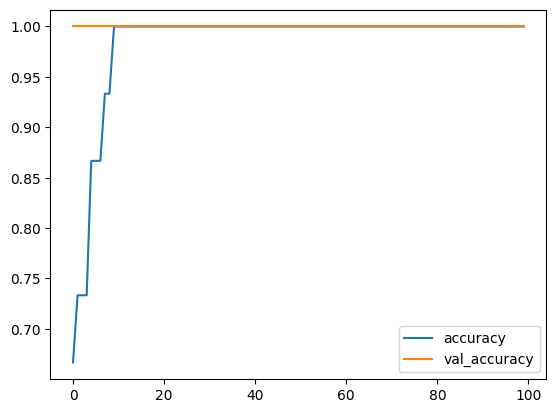

In [25]:
plt.plot(model_history.history["accuracy"], label="accuracy")
plt.plot(model_history.history["val_accuracy"], label="val_accuracy")
plt.legend()